# Exploring the Sencast lake NetCDF files

`scripts/main.py` combines the per-scene Sentinel-3 GeoTIFFs into one NetCDF per lake in `data/netcdf/sentinel3/{lake}.nc`.
Each file has dimensions `(time, lat, lon)` and one variable per product:

| Variable | Product | Units |
|---|---|---|
| `chla_oc3` | Chlorophyll-a (OC3) | mg m⁻³ |
| `tsm_binding754` | Total suspended matter (Binding 754) | g m⁻³ |
| `secchi_lee` | Secchi depth (Lee) | m |
| `forel_ule` | Forel-Ule colour index | – |

`time` is the exact acquisition time (there can be several passes per day), and `satellite` (S3A/S3B) is a coordinate along `time`.
Pixels outside the lake, under cloud, or flagged are `NaN`.

This notebook covers:
1. Opening a file and selecting data
2. Plotting a single scene as a map
3. Plotting a lake-mean time series
4. Seasonal cycle and climatology maps
5. Extracting a time series at a point
6. Comparing lakes
7. Exporting to pandas / CSV

In [1]:
import functools
import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap

DATA = Path("data/netcdf/sentinel3")
if not DATA.is_dir():  # Jupyter started from notebooks/ rather than the repository root
    DATA = Path("..") / DATA

# Plot styling: recessive axes and grid, one-hue sequential colormap for magnitudes,
# fixed-order categorical colours for comparing lakes.
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#898781",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "axes.grid": True,
    "grid.color": "#e8e7e3",
    "grid.linewidth": 0.6,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "lines.linewidth": 2,
})
SEQ = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
SEQ.set_bad("#f0efec")  # NaN (land / cloud) shown as neutral grey
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]


def rolling_median(s, window="30D", max_gap="45D"):
    """Rolling median of a time-indexed Series, with NaN inserted across data gaps
    (e.g. cloudy winters) so the plotted line breaks instead of bridging them."""
    r = s.sort_index().rolling(window, center=True).median()
    gaps = r.index.to_series().diff() > pd.Timedelta(max_gap)
    breaks = pd.Series(np.nan, index=r.index[gaps] - pd.Timedelta("1s"))
    return pd.concat([r, breaks]).sort_index()

## 1. Open a file

List the available lakes, then open one. `xr.open_dataset` is lazy, so nothing is loaded into memory until you use it.

In [2]:
@functools.cache
def open_lake(lake):
    """Open a lake's NetCDF once and reuse the handle.

    Re-opening the same file many times while another Dataset still holds it can
    crash some xarray/netCDF4 versions, so open each file once per session.
    """
    return xr.open_dataset(f"{DATA}/{lake}.nc")


lakes = sorted(os.path.basename(f)[:-3] for f in glob.glob(f"{DATA}/*.nc"))
print(len(lakes), "lakes:", ", ".join(lakes))

53 lakes: ageri, alpnachersee, ammersee, annecy, attersee, baldegg, biel, bled, bourget, brienz, caldonazzo, chiemsee, como, constance, garda, geneva, greifensee, hallstatter, hallwil, idro, iseo, joux, kochelsee, lucerne, lugano, maggiore, millstaetter, mondsee, murten, neuchatel, obertrumer, ossiacher, pfaffikon, sarnen, sempach, sihlsee, sils, silvaplana, simssee, starnberger, tegernsee, thun, traunsee, waegitaler, walchensee, walensee, wallersee, wolfgangsee, worthersee, worthsee, zeller, zug, zurich


In [3]:
lake = "geneva"
ds = open_lake(lake)
ds

<xarray.Dataset> Size: 564MB
Dimensions:         (time: 1408, lat: 117, lon: 214)
Coordinates:
  * time            (time) datetime64[ns] 11kB 2016-04-06T09:57:51 ... 2025-1...
  * lat             (lat) float64 936B 46.52 46.52 46.51 ... 46.21 46.21 46.21
  * lon             (lon) float64 2kB 6.143 6.146 6.15 ... 6.923 6.927 6.93
    satellite       (time) <U3 17kB ...
Data variables:
    spatial_ref     int32 4B ...
    tsm_binding754  (time, lat, lon) float32 141MB ...
    forel_ule       (time, lat, lon) float32 141MB ...
    chla_oc3        (time, lat, lon) float32 141MB ...
    secchi_lee      (time, lat, lon) float32 141MB ...
Attributes: (12/14)
    title:                 Sencast Sentinel-3 water quality products for geneva
    lake:                  geneva
    Conventions:           CF-1.8
    source:                Sentinel-3 OLCI processed with Sencast (https://gi...
    sencast_commit:        3d581e8d546d9d691f6a62e9bc59dae1809f3d01
    sencast_docker_image:  0.2.0
    ...                    ...
    geospatial_lat_min:    46.20371408533031
    geospatial_lat_max:    46.51928612740036
    geospatial_lon_min:    6.14076801281902
    geospatial_lon_max:    6.9322720157537905
    time_coverage_start:   2016-04-06T09:57:51
    time_coverage_end:     2025-12-31T10:05:46

### Selecting data

Standard xarray indexing works on all three dimensions. Time slicing uses strings, and `method="nearest"` finds the closest pixel or acquisition.

In [4]:
chla = ds.chla_oc3

chla.sel(time="2022")                                   # everything in 2022
chla.sel(time=slice("2020-06-01", "2020-08-31"))        # a date range
chla.sel(time="2021-07-15", method="nearest")           # the closest acquisition
chla.where(ds.satellite == "S3A", drop=True)            # only Sentinel-3A
chla.sel(lat=46.45, lon=6.55, method="nearest")         # one pixel through time

print(f"{chla.sizes['time']} acquisitions from {str(ds.time.values[0])[:10]} to {str(ds.time.values[-1])[:10]}")

1408 acquisitions from 2016-04-06 to 2025-12-31


### Lake mask and coverage

Many acquisitions are mostly cloud. A pixel is treated as lake if it is ever valid, and each scene's **coverage** is the fraction of lake pixels that are valid.
Filtering on coverage is the easiest way to drop unreliable scenes.

In [5]:
lake_mask = chla.notnull().any("time")
coverage = chla.notnull().sum(("lat", "lon")) / lake_mask.sum()

print(f"Lake pixels: {int(lake_mask.sum())}")
print(f"Scenes with >50% coverage: {int((coverage > 0.5).sum())} of {coverage.size}")

Lake pixels: 5941
Scenes with >50% coverage: 516 of 1408


## 2. Map of a single scene

Here we pick the clearest summer scene. `pcolormesh` draws the pixels, and setting the aspect to 1/cos(lat) keeps the lat/lon grid from looking stretched.

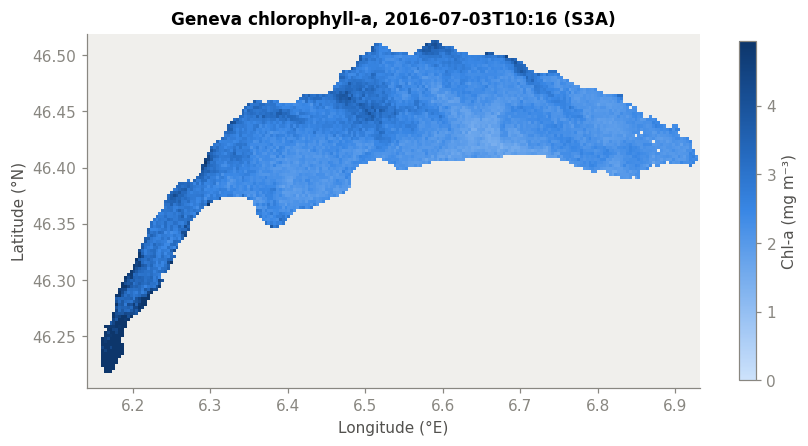

In [6]:
def lake_map(da, ax, title=None, **kwargs):
    """Draw a 2-D (lat, lon) DataArray as a map with a corrected aspect ratio."""
    im = da.plot.pcolormesh(ax=ax, x="lon", y="lat", cmap=SEQ, add_colorbar=False, **kwargs)
    ax.set_aspect(1 / np.cos(np.deg2rad(float(da.lat.mean()))))
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.grid(False)
    ax.set_title(title or "")
    return im


summer = coverage.sel(time=coverage["time.season"] == "JJA")
t_best = summer.idxmax().values
scene = chla.sel(time=t_best)

fig, ax = plt.subplots(figsize=(9, 5))
im = lake_map(scene, ax, f"{lake.title()} chlorophyll-a, {str(t_best)[:16]} ({scene.satellite.item()})",
              vmin=0, vmax=float(scene.quantile(0.98)))
fig.colorbar(im, ax=ax, label="Chl-a (mg m⁻³)", shrink=0.8)
plt.show()

### All products for that scene

Each product gets its own colour scale because the units differ.

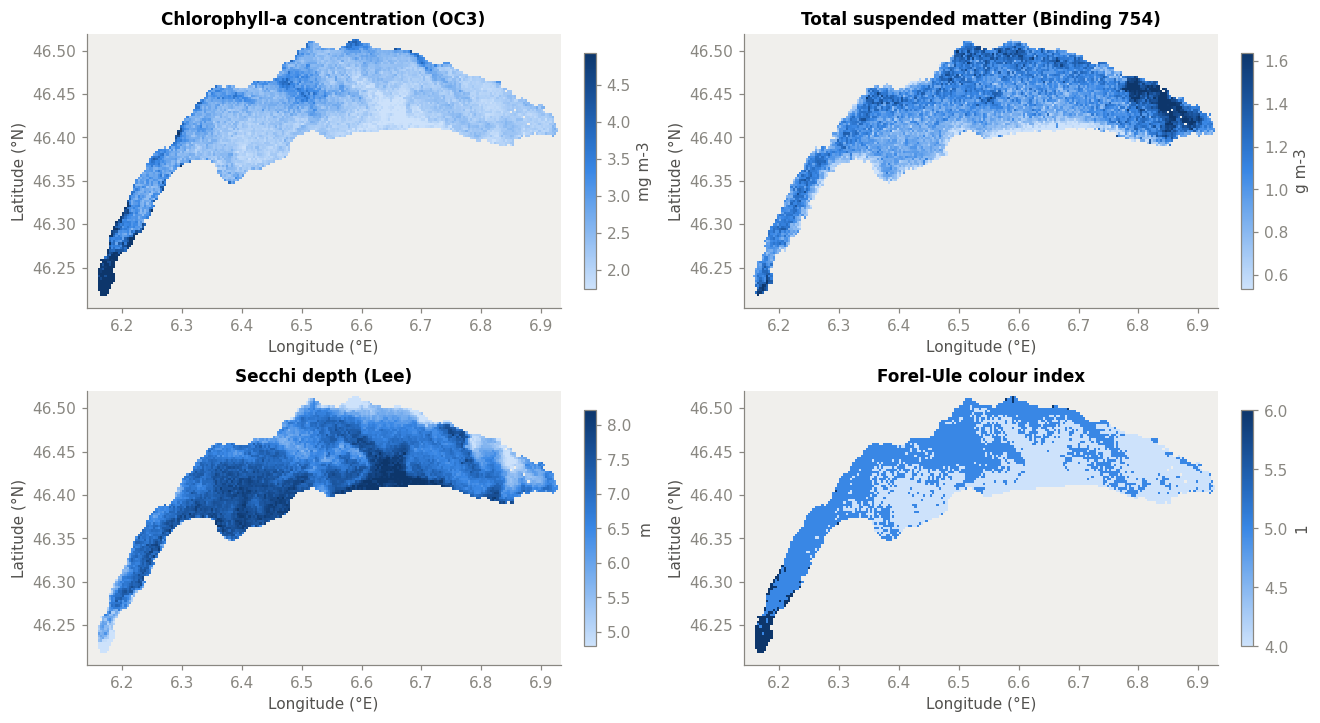

In [7]:
products = ["chla_oc3", "tsm_binding754", "secchi_lee", "forel_ule"]
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), layout="constrained")
for ax, v in zip(axes.flat, products):
    da = ds[v].sel(time=t_best)
    im = lake_map(da, ax, da.attrs["long_name"], vmin=float(da.quantile(0.02)), vmax=float(da.quantile(0.98)))
    fig.colorbar(im, ax=ax, label=da.attrs["units"], shrink=0.8)
plt.show()

## 3. Lake-mean time series

Average over space, keep scenes with more than 50% coverage, and overlay a 30-day rolling median to show the trend.

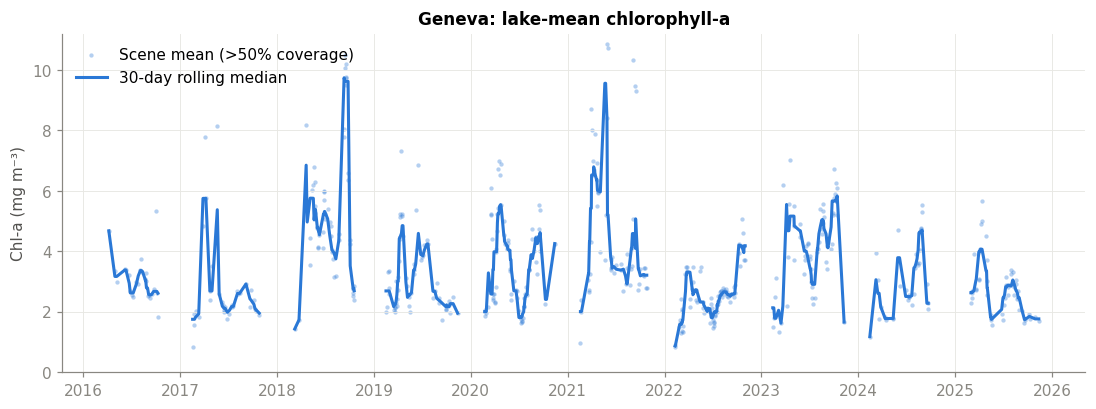

In [8]:
mean_chla = chla.mean(("lat", "lon")).where(coverage > 0.5).dropna("time")
smooth = rolling_median(mean_chla.to_series())

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(mean_chla.time, mean_chla, s=8, color=CATEGORICAL[0], alpha=0.35, linewidths=0, label="Scene mean (>50% coverage)")
ax.plot(smooth.index, smooth.values, color=CATEGORICAL[0], label="30-day rolling median")
ax.set_ylabel("Chl-a (mg m⁻³)")
ax.set_title(f"{lake.title()}: lake-mean chlorophyll-a")
ax.set_ylim(0, float(mean_chla.quantile(0.99)) * 1.1)
ax.legend(frameon=False, loc="upper left")
plt.show()

### Several products as small multiples

Each product gets its own panel instead of sharing a dual axis, because their units and scales differ.

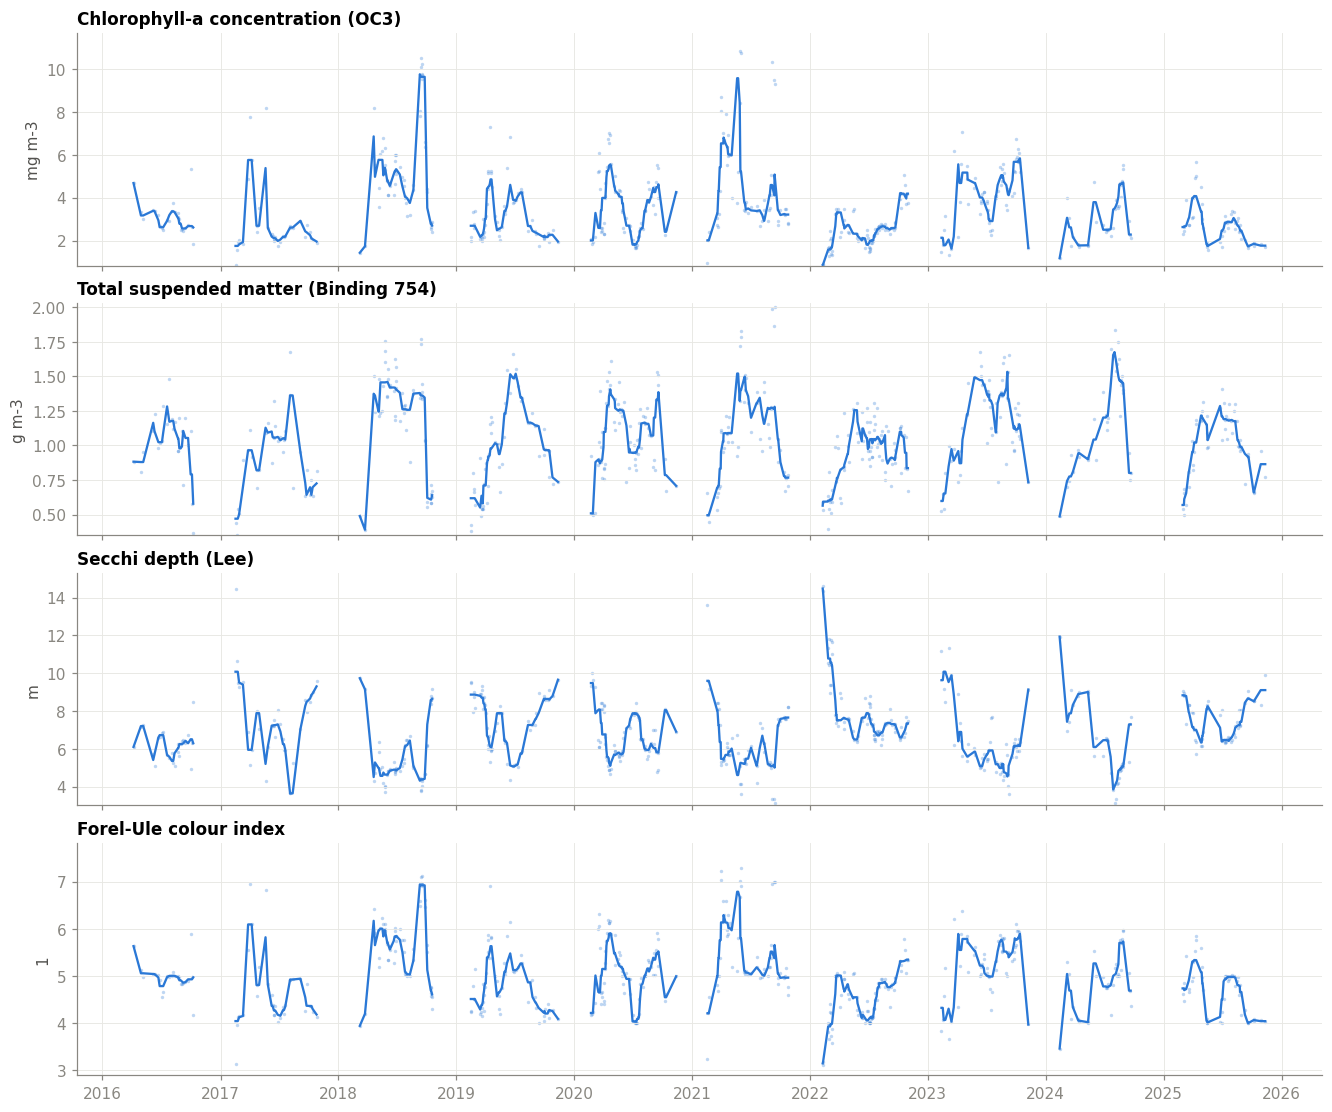

In [9]:
fig, axes = plt.subplots(len(products), 1, figsize=(12, 10), sharex=True, layout="constrained")
for ax, v in zip(axes, products):
    s = ds[v].mean(("lat", "lon")).where(coverage > 0.5).dropna("time").to_series()
    ax.scatter(s.index, s.values, s=5, color=CATEGORICAL[0], alpha=0.3, linewidths=0)
    ax.plot(rolling_median(s), color=CATEGORICAL[0], linewidth=1.5)
    ax.set_ylabel(ds[v].attrs["units"])
    ax.set_title(ds[v].attrs["long_name"], loc="left")
    ax.set_ylim(s.quantile(0.005) * 0.9, s.quantile(0.995) * 1.1)
plt.show()

## 4. Seasonal cycle and climatology

`groupby` on `time.month` / `time.year` gives climatologies in a single line.

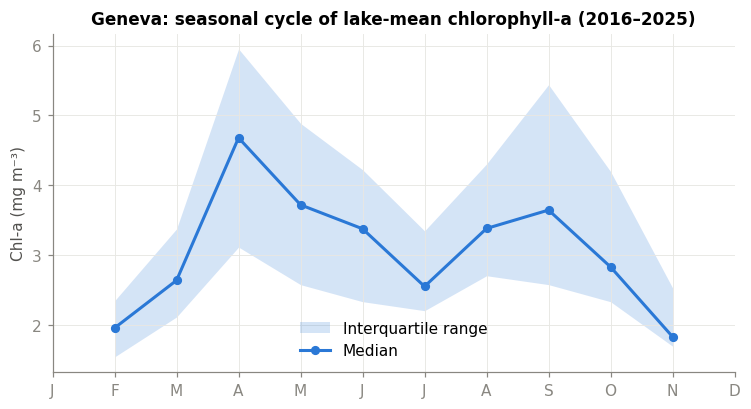

In [10]:
monthly = mean_chla.groupby("time.month")
med, q25, q75 = monthly.median(), monthly.quantile(0.25), monthly.quantile(0.75)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(med.month, q25, q75, color=CATEGORICAL[0], alpha=0.2, linewidth=0, label="Interquartile range")
ax.plot(med.month, med, color=CATEGORICAL[0], marker="o", markersize=5, label="Median")
ax.set_xticks(range(1, 13), ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_ylabel("Chl-a (mg m⁻³)")
ax.set_title(f"{lake.title()}: seasonal cycle of lake-mean chlorophyll-a (2016–2025)")
ax.legend(frameon=False)
plt.show()

### Seasonal climatology maps

Taking the per-pixel median over all scenes in each season (NaNs are ignored) brings out spatial patterns. Here the colour scale is shared across panels so they can be compared directly.

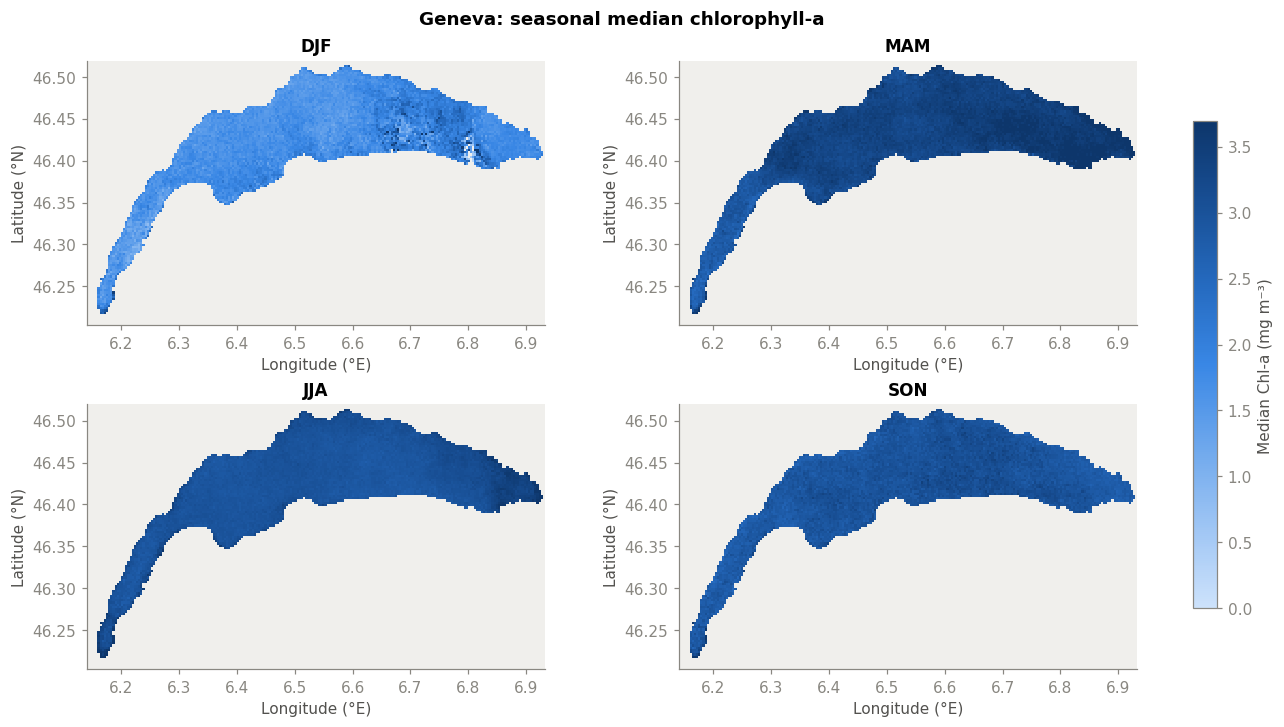

In [11]:
clim = chla.groupby("time.season").median("time").sel(season=["DJF", "MAM", "JJA", "SON"])
vmax = float(clim.quantile(0.98))

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), layout="constrained")
for ax, season in zip(axes.flat, clim.season.values):
    im = lake_map(clim.sel(season=season), ax, season, vmin=0, vmax=vmax)
fig.colorbar(im, ax=axes, label="Median Chl-a (mg m⁻³)", shrink=0.8)
fig.suptitle(f"{lake.title()}: seasonal median chlorophyll-a", fontweight="bold")
plt.show()

### Year-by-year summer maps

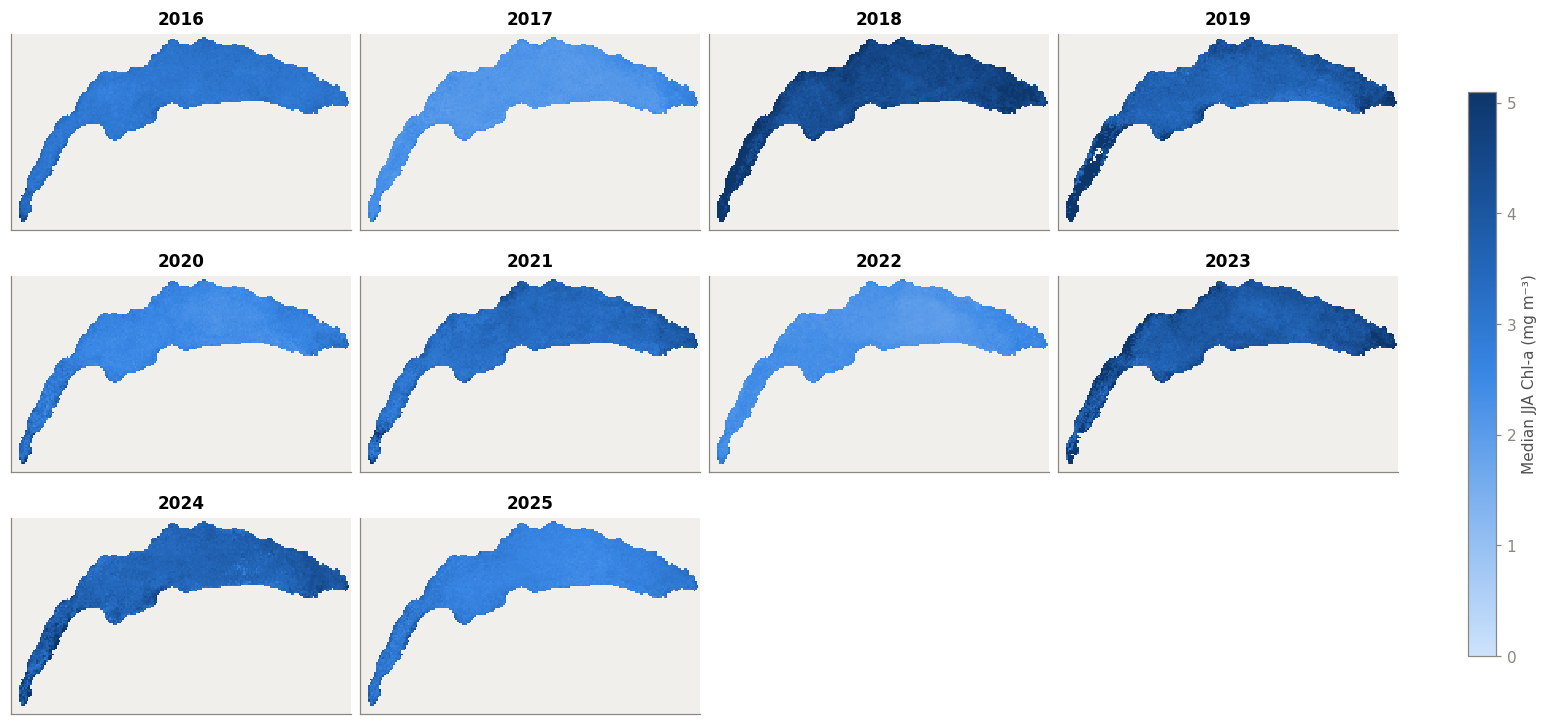

In [12]:
summer_by_year = chla.where(chla["time.season"] == "JJA").groupby("time.year").median("time").dropna("year", how="all")
vmax = float(summer_by_year.quantile(0.98))

n = summer_by_year.sizes["year"]
fig, axes = plt.subplots(int(np.ceil(n / 4)), 4, figsize=(14, 2.2 * np.ceil(n / 4)), layout="constrained")
for ax in axes.flat[n:]:
    ax.remove()
for ax, yr in zip(axes.flat, summer_by_year.year.values):
    im = lake_map(summer_by_year.sel(year=yr), ax, str(yr), vmin=0, vmax=vmax)
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=list(axes.flat[:n]), label="Median JJA Chl-a (mg m⁻³)", shrink=0.8)
plt.show()

## 5. Time series at a point

`method="nearest"` snaps a coordinate, for example a monitoring station, to the nearest pixel. A small window averaged around it gives a less noisy signal.

Nearest pixel centre: 46.4505 N, 6.5901 E


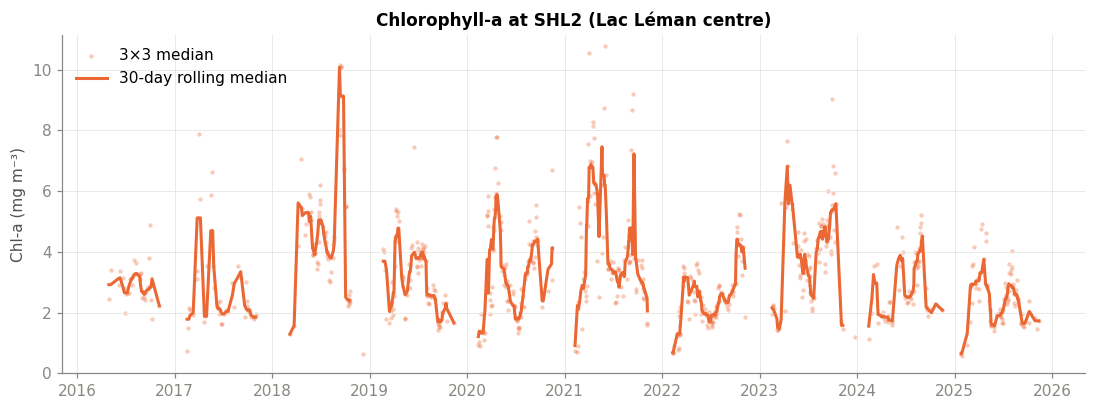

In [13]:
station = {"name": "SHL2 (Lac Léman centre)", "lat": 46.45, "lon": 6.59}

pixel = chla.sel(lat=station["lat"], lon=station["lon"], method="nearest")
print(f"Nearest pixel centre: {float(pixel.lat):.4f} N, {float(pixel.lon):.4f} E")

# 3x3 window around the nearest pixel
iy = int(np.abs(chla.lat - station["lat"]).argmin())
ix = int(np.abs(chla.lon - station["lon"]).argmin())
window = chla.isel(lat=slice(iy - 1, iy + 2), lon=slice(ix - 1, ix + 2)).median(("lat", "lon"))

fig, ax = plt.subplots(figsize=(12, 4))
s = window.dropna("time").to_series()
ax.scatter(s.index, s.values, s=8, color=CATEGORICAL[1], alpha=0.35, linewidths=0, label="3×3 median")
ax.plot(rolling_median(s), color=CATEGORICAL[1], label="30-day rolling median")
ax.set_ylabel("Chl-a (mg m⁻³)")
ax.set_ylim(0, s.quantile(0.99) * 1.1)
ax.set_title(f"Chlorophyll-a at {station['name']}")
ax.legend(frameon=False, loc="upper left")
plt.show()

## 6. Comparing lakes

Each lake has its own grid, so reduce each one to a lake-mean series first and then combine them in pandas.

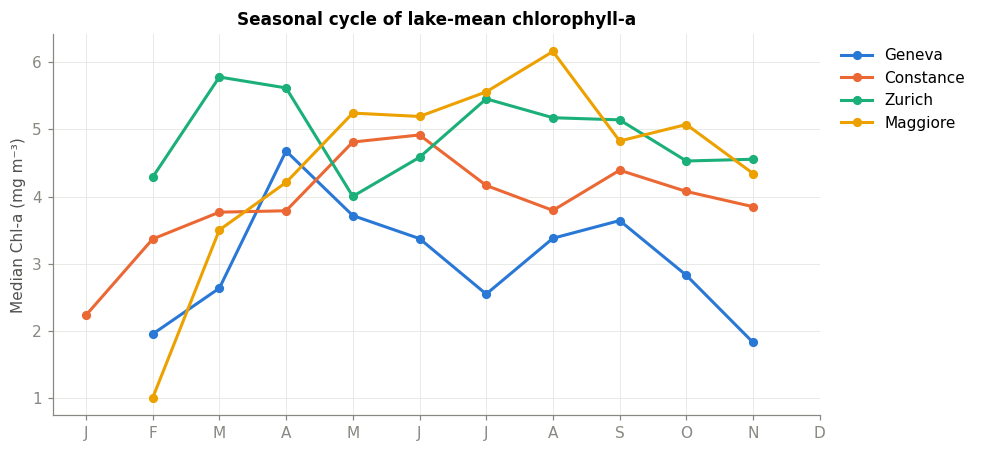

In [14]:
def lake_mean(lake, var="chla_oc3", min_coverage=0.5):
    da = open_lake(lake)[var]
    cov = da.notnull().sum(("lat", "lon")) / da.notnull().any("time").sum()
    return da.mean(("lat", "lon")).where(cov > min_coverage).dropna("time").to_series().rename(lake)


compare = ["geneva", "constance", "zurich", "maggiore"]
series = {l: lake_mean(l) for l in compare}

fig, ax = plt.subplots(figsize=(9, 4.5))
for color, (l, s) in zip(CATEGORICAL, series.items()):
    m = s.groupby(s.index.month).median()
    ax.plot(m.index, m.values, color=color, marker="o", markersize=5, label=l.title())
ax.set_xticks(range(1, 13), ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_ylabel("Median Chl-a (mg m⁻³)")
ax.set_title("Seasonal cycle of lake-mean chlorophyll-a")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.show()

### Summary table across all lakes

In [15]:
rows = []
for l in lakes:
    s = lake_mean(l)
    rows.append({
        "lake": l,
        "scenes (>50% cover)": len(s),
        "first": s.index.min().date(),
        "last": s.index.max().date(),
        "median chl-a": s.median(),
        "summer median chl-a": s[s.index.month.isin([6, 7, 8])].median(),
    })
summary = pd.DataFrame(rows).set_index("lake").sort_values("median chl-a", ascending=False)
summary.round(2)

,scenes (>50% cover),first,last,median chl-a,summer median chl-a
lake,,,,,
simssee,1,2017-03-31,2017-03-31,27.830000,NaN
sihlsee,68,2016-04-10,2025-07-18,17.410000,17.60
pfaffikon,7,2017-03-23,2023-10-28,17.190001,NaN
greifensee,26,2016-07-07,2025-10-07,17.090000,15.62
wallersee,3,2017-07-05,2022-06-05,17.040001,16.29
alpnachersee,13,2016-07-30,2023-07-20,15.790000,14.78
ammersee,44,2016-05-26,2025-09-18,15.700000,18.58
joux,11,2017-10-17,2025-06-28,13.700000,15.17
idro,76,2016-04-14,2025-08-26,13.070000,17.08


## 7. Export to pandas / CSV

`to_dataframe()` flattens a dataset to one row per (time, lat, lon). Drop the NaNs first, because most of the grid is land or cloud.

In [ ]:
# Lake-mean time series of every product, one row per scene
lake_ts = (ds[products].mean(("lat", "lon"))
           .assign(coverage=coverage, satellite=ds.satellite)
           .to_dataframe()
           .drop(columns="spatial_ref", errors="ignore"))
lake_ts = lake_ts[lake_ts.coverage > 0.5]
lake_ts.head()

In [ ]:
# Full pixel table for one month (long format)
pixels = ds[products].sel(time="2022-07").to_dataframe().dropna(how="all", subset=products)
print(f"{len(pixels):,} rows")
pixels.head()

# lake_ts.to_csv(f"{lake}_timeseries.csv")